In [1]:
#### HOUSE PRICE PREDICTION  ####

# STEP 1

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
import seaborn as sns

pd.set_option("display.max_rows", None, "display.max_columns", None)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
df = pd.read_csv('house-price-data.csv')

In [4]:
df['SaleCondition'].value_counts()

Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: SaleCondition, dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
label = LabelEncoder()

x =label.fit_transform(df['SaleCondition']) 

xy = pd.get_dummies(df['SaleCondition'])

In [7]:
xy

,Abnorml,AdjLand,Alloca,Family,Normal,Partial
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,1,0,0,0,0,0
4,0,0,0,0,1,0
5,0,0,0,0,1,0
6,0,0,0,0,1,0
7,0,0,0,0,1,0
8,1,0,0,0,0,0
9,0,0,0,0,1,0


In [8]:
df['SaleCondition'].value_counts()

Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: SaleCondition, dtype: int64

In [9]:
df['SaleCondition']

0        Normal
1        Normal
2        Normal
3       Abnorml
4        Normal
5        Normal
6        Normal
7        Normal
8       Abnorml
9        Normal
10       Normal
11      Partial
12       Normal
13      Partial
14       Normal
15       Normal
16       Normal
17       Normal
18       Normal
19      Abnorml
20      Partial
21       Normal
22       Normal
23       Normal
24       Normal
25       Normal
26       Normal
27       Normal
28       Normal
29       Normal
30       Normal
31       Normal
32       Normal
33       Normal
34       Normal
35       Normal
36       Normal
37       Normal
38      Abnorml
39      AdjLand
40      Abnorml
41       Normal
42       Normal
43       Normal
44       Normal
45       Normal
46      Abnorml
47       Normal
48      Partial
49       Normal
50       Normal
51       Normal
52       Normal
53       Normal
54       Normal
55       Normal
56      Abnorml
57       Normal
58      Partial
59       Normal
60      Partial
61       Normal
62      

In [10]:
df.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [11]:
df.tail(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [12]:
df.shape

(1460, 81)

In [13]:
df['MSZoning'].value_counts()

RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: MSZoning, dtype: int64

In [14]:
df.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType          8
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [15]:
#df.info

In [16]:
#df.describe

<AxesSubplot:>

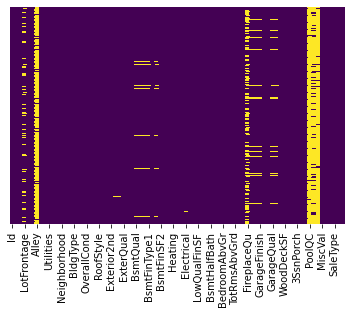

In [17]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis') #Check null values through heatmap

In [18]:
#df['LotFrontage']

In [19]:
df['LotFrontage'].mean()

70.04995836802665

## STEP 2

In [20]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean()) #Fill NA values with appropriate value

In [21]:
df.drop(['Alley'],axis=1,inplace=True) #Drop columns that are not needed

In [22]:
df.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [23]:
df.shape

(1460, 80)

In [24]:
1,1,1,1,1,1,2,2,2,3,3

(1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3)

In [25]:
df['BsmtCond'].value_counts()

TA    1311
Gd      65
Fa      45
Po       2
Name: BsmtCond, dtype: int64

In [26]:
df['BsmtCond'].mode()[0]

'TA'

In [27]:
df['BsmtCond'] = df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])
df['BsmtQual'] = df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])
df['FireplaceQu'] = df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])
df['GarageType'] = df['GarageType'].fillna(df['GarageType'].mode()[0])

In [28]:
df.drop(['GarageYrBlt'],axis=1,inplace=True)

In [29]:
df['GarageFinish'] = df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual'] = df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond'] = df['GarageCond'].fillna(df['GarageCond'].mode()[0])
#df['GarageType'] = df['GarageType'].fillna(df['GarageType'].mode()[0])

In [30]:
df.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [31]:
df.drop(['Id'],axis=1,inplace=True)

In [32]:
df.shape

(1460, 75)

In [33]:
#df.columns

In [34]:
df.isnull().sum()

MSSubClass        0
MSZoning          0
LotFrontage       0
LotArea           0
Street            0
LotShape          0
LandContour       0
Utilities         0
LotConfig         0
LandSlope         0
Neighborhood      0
Condition1        0
Condition2        0
BldgType          0
HouseStyle        0
OverallQual       0
OverallCond       0
YearBuilt         0
YearRemodAdd      0
RoofStyle         0
RoofMatl          0
Exterior1st       0
Exterior2nd       0
MasVnrType        8
MasVnrArea        8
ExterQual         0
ExterCond         0
Foundation        0
BsmtQual          0
BsmtCond          0
BsmtExposure     38
BsmtFinType1     37
BsmtFinSF1        0
BsmtFinType2     38
BsmtFinSF2        0
BsmtUnfSF         0
TotalBsmtSF       0
Heating           0
HeatingQC         0
CentralAir        0
Electrical        1
1stFlrSF          0
2ndFlrSF          0
LowQualFinSF      0
GrLivArea         0
BsmtFullBath      0
BsmtHalfBath      0
FullBath          0
HalfBath          0
BedroomAbvGr      0


In [35]:
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0])

<AxesSubplot:>

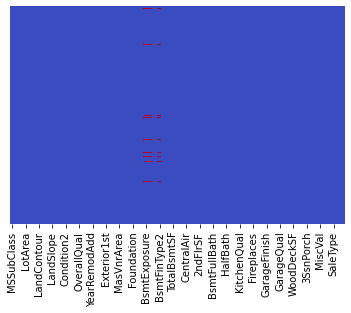

In [36]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [37]:
#sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [38]:
df['BsmtExposure'] = df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])

In [39]:
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(df['BsmtFinType1'].mode()[0])

<AxesSubplot:>

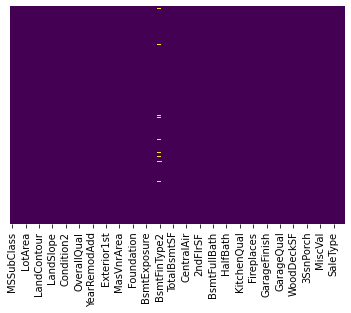

In [40]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [41]:
df.dropna(inplace=True)

<AxesSubplot:>

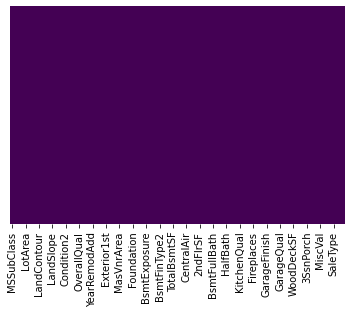

In [42]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [43]:
df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500


In [44]:
df.shape

(1421, 75)

In [45]:
#df.isnull().sum()

<AxesSubplot:>

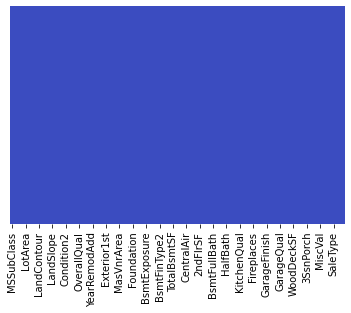

In [46]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [47]:
col = df.columns

In [48]:
col

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF'

In [49]:
len(col)

75

In [50]:
numeric = list(df.dtypes[df.dtypes!='object'].index)

In [51]:
numeric

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [52]:
len(numeric)

36

In [53]:
#df['YrSold']

In [54]:
df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500


In [55]:
train = df[numeric]

In [56]:
train.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007,181500


In [57]:
type(train)

pandas.core.frame.DataFrame

In [58]:
#train_scaled

In [60]:
train.shape

(1421, 36)

In [61]:
train.isnull().sum()

MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

In [62]:
#xtest

In [64]:
#train.iloc[row_starting_index : row_ending_index , col_starting_index : col_ending_index]

In [65]:
price = train.iloc[:,35:36] #OUTPUT

#price = train['SalePrice']
price.head(2)

,SalePrice
0,208500
1,181500


In [67]:
train = train.iloc[:,:-1]  #INPUT
train.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007


In [68]:
#100% ....80% training 20% test

In [157]:
#input = 100
#output = 100


#training_input = 80    #xtrain
#training_output = 80   #ytrain

#test_input = 20    #xtest
#testing_output = 20  #ytest



#random state

#100 .... 

#80 training data ...randomly selected data out of 100
#20 testing data


#80 ... model accuracy = 85
#20 ...  model accuracy = 75


In [153]:
#Splitting the dataset into training and testing data
xtrain,xtest,ytrain,ytest = train_test_split(train,
                                             price,
                                             test_size=0.2,
                                             random_state=40)

In [154]:
print(len(xtrain), len(ytrain),len(xtest),len(ytest))

1136 1136 285 285


In [155]:
xtrain.head(10)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
168,60,62.000000,8244,7,5,2004,2004,0.0,0,0,840,840,840,880,0,1720,0,0,2,1,3,1,7,1,2,440,100,48,0,0,0,0,0,5,2007
228,20,70.000000,8521,5,5,1967,1967,0.0,842,0,70,912,912,0,0,912,0,0,1,0,3,1,5,1,1,336,0,0,0,0,0,0,0,5,2010
1097,120,70.049958,3696,8,5,1986,1986,0.0,0,0,1074,1074,1088,0,0,1088,0,0,1,1,2,1,5,0,2,461,0,74,137,0,0,0,0,10,2007
884,20,65.000000,7150,5,5,1967,1967,60.0,432,0,460,892,892,0,0,892,0,0,1,0,3,1,5,0,1,288,0,0,0,0,0,0,0,7,2009
1297,180,35.000000,3675,6,5,2005,2006,82.0,547,0,0,547,1072,0,0,1072,1,0,2,0,2,1,5,0,2,525,0,44,0,0,0,0,0,6,2006
447,60,70.049958,11214,7,5,1998,1999,0.0,0,0,930,930,956,930,0,1886,0,0,2,1,4,1,10,1,2,431,89,0,0,0,0,0,0,7,2006
788,20,50.000000,6000,4,7,1954,2000,0.0,0,0,901,901,901,0,0,901,0,0,1,0,2,1,4,0,1,281,0,0,0,0,0,0,0,8,2008
978,20,68.000000,9450,4,5,1954,1954,0.0,552,0,342,894,894,0,0,894,0,0,1,0,3,1,5,0,2,400,0,0,0,0,0,0,0,5,2007
929,60,70.049958,13006,7,5,1997,1997,285.0,0,0,964,964,993,1243,0,2236,0,0,2,1,4,1,8,1,2,642,0,0,0,0,0,0,0,11,2006
284,120,50.000000,8012,6,5,1992,1992,0.0,430,0,1145,1575,1575,0,0,1575,1,0,2,0,2,1,5,0,2,529,0,0,52,0,0,0,0,7,2007


In [151]:
#ytrain

In [74]:
#xtest

In [75]:
#ytest

In [77]:
ytrain.head(2)

,SalePrice
168,183500
228,125000


## STEP 3

In [81]:
# PREPROCESSING ##################

In [82]:
from sklearn.preprocessing import StandardScaler

In [83]:
scaler = StandardScaler()

In [84]:
###INPUT DATA TRANSFORMATION

In [85]:
xtrain_scaled = scaler.fit_transform(xtrain)

In [86]:
xtrain_scaled

array([[ 1.01097709e-01, -3.72341154e-01, -2.30311686e-01, ...,
        -1.09597356e-01, -5.06922501e-01, -6.06445742e-01],
       [-8.54964708e-01, -1.08424403e-03, -2.05038876e-01, ...,
        -1.09597356e-01, -5.06922501e-01,  1.66223383e+00],
       [ 1.53519134e+00,  1.23417964e-03, -6.45260209e-01, ...,
        -1.09597356e-01,  1.34711472e+00, -6.06445742e-01],
       ...,
       [ 1.01097709e-01,  1.23417964e-03, -3.52457365e-02, ...,
         1.08054600e+00,  1.71792216e+00,  9.06007305e-01],
       [ 2.49125375e+00, -2.27503282e+00, -8.29195174e-01, ...,
        -1.09597356e-01, -5.06922501e-01,  9.06007305e-01],
       [-8.54964708e-01, -1.30048343e+00,  3.76235758e-01, ...,
        -1.09597356e-01,  1.34711472e+00,  9.06007305e-01]])

In [87]:
#xtrain_scaled

In [88]:
xtest_scaled = scaler.transform(xtest)

In [89]:
#ytest

In [90]:
### FIT TRANSFORM - Training Data
### TRANSFORM - Testing Data


In [91]:
regressor = LinearRegression()   #Initialize linear regressor

In [92]:
regressor.fit(xtrain_scaled,ytrain)   #Train the model

LinearRegression()

In [93]:
 regressor.score(xtrain_scaled,ytrain)   #Check accuracy on training data

0.8547451760905891

In [94]:
 regressor.score(xtest_scaled,ytest)    #Check accuracy on testing data

0.5190412461276942

In [95]:
reg = regressor.predict(xtest_scaled)    #Predict the house price

In [96]:
reg.shape

(285, 1)

In [97]:
ytest_li = []
for i in ytest.SalePrice:
    ytest_li.append(i)

In [98]:
for i in range(len(reg)):
    print(reg[i] , ytest_li[i])

[217561.56620916] 222000
[238284.03095065] 207500
[186449.32202786] 181000
[155391.81998189] 144500
[290398.76767639] 293077
[163092.64829566] 155000
[252692.61249775] 260400
[112824.15388529] 119000
[199241.17512403] 173000
[103700.52251329] 108000
[202841.098225] 201000
[284599.49036773] 240000
[284990.85666211] 270000
[47127.48252417] 151500
[149145.04289339] 143000
[155954.04602563] 169900
[173023.22371134] 163000
[227647.07762851] 245500
[144098.42118983] 160000
[277325.84281642] 250000
[145255.83756344] 157500
[108516.78438971] 114500
[289191.36351704] 268000
[300828.23156183] 314813
[51478.60669583] 80000
[318622.55977382] 340000
[322264.95080436] 337000
[222205.22026898] 250000
[198149.16812928] 194000
[101688.19740278] 110000
[215693.9766429] 214000
[190193.93053788] 176000
[61648.62210881] 83000
[128312.89449722] 117000
[210834.81961367] 176000
[110319.77657199] 120000
[159210.95156349] 144000
[145932.36478534] 134000
[84795.25885475] 79000
[185738.86806294] 172500
[212930.69

In [99]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [100]:
ytest_scaled = scaler.fit_transform(ytest)

In [101]:
reg_scaled = scaler.transform(reg)     #Need to transform the predicted price to check mse and mae

In [102]:
reg_scaled

array([[ 4.15134035e-01],
       [ 6.77808452e-01],
       [ 2.07605516e-02],
       [-3.72919030e-01],
       [ 1.33840594e+00],
       [-2.75304648e-01],
       [ 8.60449166e-01],
       [-9.12499481e-01],
       [ 1.82907893e-01],
       [-1.02814907e+00],
       [ 2.28539902e-01],
       [ 1.26489529e+00],
       [ 1.26985618e+00],
       [-1.74525925e+00],
       [-4.52102107e-01],
       [-3.65792349e-01],
       [-1.49426373e-01],
       [ 5.42976252e-01],
       [-5.16072220e-01],
       [ 1.17269578e+00],
       [-5.01401009e-01],
       [-9.67098960e-01],
       [ 1.32310109e+00],
       [ 1.47060804e+00],
       [-1.69010514e+00],
       [ 1.69616590e+00],
       [ 1.74233622e+00],
       [ 4.73996199e-01],
       [ 1.69065799e-01],
       [-1.05365696e+00],
       [ 3.91460789e-01],
       [ 6.82265683e-02],
       [-1.56119177e+00],
       [-7.16166856e-01],
       [ 3.29866946e-01],
       [-9.44244540e-01],
       [-3.24508371e-01],
       [-4.92825465e-01],
       [-1.2

In [103]:
#mean_squared_error(ytest,reg) #mean_squared_error

In [104]:
mean_squared_error(ytest_scaled,reg_scaled) #mean_squared_error

0.4809587538723058

In [105]:
mean_squared_error(ytest_scaled,reg_scaled, squared=False) #root_mean_squared_error

0.6935118988685817

In [106]:
mean_absolute_error(ytest_scaled,reg_scaled) #mean_absolute_error

0.2992732035483763

In [ ]:
#Linear regressor does not perform well

In [107]:
######Test Set

In [108]:
test = pd.read_csv('house-price-data.csv')    #test the model on any other data

In [109]:
test.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [110]:
test.shape

(1460, 81)

In [111]:
test = pd.read_csv('house-price-data.csv')

#test.info()

#test.isnull().sum()
test['MSZoning'].value_counts()


test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].mean())

test.drop(['Alley'],axis=1,inplace=True)

test['MSZoning'] = test['MSZoning'].fillna(test['MSZoning'].mode()[0])

test['BsmtCond'] = test['BsmtCond'].fillna(test['BsmtCond'].mode()[0])
test['BsmtQual'] = test['BsmtQual'].fillna(test['BsmtQual'].mode()[0])
test['FireplaceQu'] = test['FireplaceQu'].fillna(test['FireplaceQu'].mode()[0])
test['GarageType'] = test['GarageType'].fillna(test['GarageType'].mode()[0])

test.drop(['GarageYrBlt'],axis=1,inplace=True)

test['GarageFinish'] = test['GarageFinish'].fillna(test['GarageFinish'].mode()[0])
test['GarageQual'] = test['GarageQual'].fillna(test['GarageQual'].mode()[0])
test['GarageCond'] = test['GarageCond'].fillna(test['GarageCond'].mode()[0])
test['GarageType'] = test['GarageType'].fillna(test['GarageType'].mode()[0])

test.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

test.drop(['Id'],axis=1,inplace=True)

#test.shape

#test.columns

test['MasVnrType'] = test['MasVnrType'].fillna(test['MasVnrType'].mode()[0])
test['MasVnrArea'] = test['MasVnrArea'].fillna(test['MasVnrArea'].mode()[0])

test['BsmtExposure'] = test['BsmtExposure'].fillna(test['BsmtExposure'].mode()[0])
test['BsmtFinType2'] = test['BsmtFinType2'].fillna(test['BsmtFinType2'].mode()[0])


test.dropna(inplace=True)

#test.shape

#test.shape

#test.isnull().sum()

test['MasVnrType'] = test['MasVnrType'].fillna(test['MasVnrType'].mode()[0])
test['MasVnrArea'] = test['MasVnrArea'].fillna(test['MasVnrArea'].mode()[0])

test['BsmtExposure'] = test['BsmtExposure'].fillna(test['BsmtExposure'].mode()[0])


#test.drop(['Id'],axis=1,inplace=True)

test['BsmtExposure'] = test['BsmtExposure'].fillna(test['BsmtExposure'].mode()[0])


numeric = list(test.dtypes[test.dtypes!='object'].index)

test = test[numeric]

#test.shape


RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: MSZoning, dtype: int64

In [112]:
test.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007,181500


In [113]:
################### Training the model using random forest 

In [114]:
from sklearn.ensemble import RandomForestRegressor

In [115]:
regr =RandomForestRegressor()

In [116]:
regr.fit(xtrain_scaled,ytrain)

<ipython-input-116-ebeacc4026c2>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  regr.fit(xtrain_scaled,ytrain)


RandomForestRegressor()

In [117]:
regr.score(xtrain_scaled,ytrain)

0.9791999591081592

In [118]:
regr.score(xtest_scaled,ytest)

0.8287579473392014

In [119]:
predicted_value = regr.predict(xtest_scaled)

In [120]:
predicted_value.shape

(285,)

In [121]:
#predicted_value

In [122]:
ytest_li = []
for i in ytest.SalePrice:
    ytest_li.append(i)

In [123]:
for i in range(len(predicted_value)):
    #print(predicted_value[i] , ytest_li[i])
    pass

In [124]:
ytest_scaled2 = scaler.fit_transform(ytest)   #Need to transform to check MSE and MAE

In [125]:
#ytest_scaled2

In [126]:
reg_scaled2 = scaler.transform(predicted_value.reshape(-1,1))

In [127]:
#reg_scaled2

In [128]:
#reg_scaled2 = scaler.transform(reg_scaled2)

In [129]:
mean_squared_error(ytest_scaled2,reg_scaled2)

0.1712420526607986

In [130]:
mean_squared_error(ytest_scaled2,reg_scaled2, squared = False) #RMSE

0.41381403149337337

In [131]:
mean_absolute_error(ytest_scaled2,reg_scaled2)

0.2361065827395854

In [132]:
predicted_value

array([202428.5       , 235874.42      , 176440.4       , 151801.68      ,
       311472.11      , 163863.92      , 243292.94      , 119610.83      ,
       161711.55      , 118812.58      , 194586.5       , 269222.2       ,
       303640.16      , 132072.5       , 138675.5       , 144538.5       ,
       155607.5       , 233457.56      , 141618.57      , 274843.48      ,
       152180.25      , 122759.4       , 336282.34      , 291497.78      ,
        82571.11      , 327256.11      , 334775.66      , 216033.        ,
       196100.09      , 120325.61      , 199300.67      , 163214.68      ,
        95648.98      , 118318.        , 213139.79      , 119772.7       ,
       150024.01      , 147545.74      , 114925.34      , 173510.55      ,
       210428.49      , 133356.86      , 113323.86      , 220104.63      ,
       109923.93      , 368498.5       , 184095.95      , 201458.98      ,
       124173.5       , 116973.29      , 314873.14      , 128246.        ,
       156462.72      , 1

In [133]:
#######################################################

In [134]:
#######################################################

In [135]:
#predicted_value.to_list()

In [136]:
#pre = predicted_value.tolist()

In [139]:
pre = predicted_value.tolist()

In [140]:
predicted_value.shape

(285,)

In [141]:
li =[]
li.append(pre)

In [142]:
predicted_value

array([202428.5       , 235874.42      , 176440.4       , 151801.68      ,
       311472.11      , 163863.92      , 243292.94      , 119610.83      ,
       161711.55      , 118812.58      , 194586.5       , 269222.2       ,
       303640.16      , 132072.5       , 138675.5       , 144538.5       ,
       155607.5       , 233457.56      , 141618.57      , 274843.48      ,
       152180.25      , 122759.4       , 336282.34      , 291497.78      ,
        82571.11      , 327256.11      , 334775.66      , 216033.        ,
       196100.09      , 120325.61      , 199300.67      , 163214.68      ,
        95648.98      , 118318.        , 213139.79      , 119772.7       ,
       150024.01      , 147545.74      , 114925.34      , 173510.55      ,
       210428.49      , 133356.86      , 113323.86      , 220104.63      ,
       109923.93      , 368498.5       , 184095.95      , 201458.98      ,
       124173.5       , 116973.29      , 314873.14      , 128246.        ,
       156462.72      , 1

In [144]:
result = pd.DataFrame({"Actual price":ytest_li,"Predicted price":predicted_value})

In [145]:
#result

In [146]:
result.to_csv("house-price.csv",index=False) #to save result in csv file